In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils.data_loader import find_repo_root
from pathlib import Path

# Load Data

In [2]:
sampling_rate = '5min'  # available: '20s', '1min', '5min'
columns =['orbital_decay', 'trend', '|avg B|', 'F10.7 (LASP)']

DATA_DIR = find_repo_root() / Path("Dataset/modeling/")
DATA_file = DATA_DIR / Path(f"GFOC_modeling_{sampling_rate}.parquet")
GFOC_data = pd.read_parquet(DATA_file, columns=columns)
print(f"✅ Successfully loaded data with shape: {GFOC_data.shape}")

✅ Successfully loaded data with shape: (210528, 4)


# Subsets

In [11]:
Subset_DIR = find_repo_root() / Path("Analysis/Subsets/")
Subset_names = ['Kp', 'eflag_meanstd'] #, 'merged', 'eflag_meanstd', 'eflag', 'meanstd'

for name in Subset_names:
    filename = 'subsets_' + name + '.csv'
    subset = pd.read_csv(Subset_DIR / filename)
    GFOC_data[name] = None

    # mo flags
    interval_starts = pd.to_datetime(subset['start']).dropna()

    interval_ends = pd.to_datetime(subset['end']).dropna()

    intervals = list(zip(interval_starts, interval_ends))
    i = 1
    for start, end in intervals:
        GFOC_data[name].loc[(GFOC_data.index >= start) & (GFOC_data.index <= end)] = i
        i += 1

C:\Users\david\AppData\Local\Temp\ipykernel_19532\2395022959.py:17: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  GFOC_data[name].loc[(GFOC_data.index >= start) & (GFOC_data.index <= end)] = i
C:\Users\david\AppData\Local\Temp\ipykernel_1953

# Folds for different Subsets

In [3]:
# Subset 1
folds_1 = [
    ("1st train", "train", "2023-01-03 01:30:00", "2023-03-18 04:25:00"),
    ("1st val",   "val",   "2023-03-18 04:30:00", "2023-07-18 19:10:00"),

    ("2nd train", "train", "2023-01-03 01:30:00", "2023-07-18 19:10:00"),
    ("2nd val",   "val",   "2023-07-18 19:15:00", "2023-10-01 22:45:00"),

    ("3rd train", "train", "2023-01-03 01:30:00", "2023-10-01 22:45:00"),
    ("3rd val",   "val",   "2023-10-01 22:50:00", "2023-12-28 14:20:00"),

    ("4th train", "train", "2023-01-03 01:30:00", "2023-12-28 14:20:00"),
    ("4th val",   "val",   "2023-12-28 14:25:00", "2024-04-19 08:00:00"),

    ("5th train", "train", "2023-01-03 01:30:00", "2024-04-19 08:00:00"),
    ("5th val",   "val",   "2024-04-19 08:05:00", "2024-06-30 04:00:00"),

    ("final train", "train", "2023-01-03 01:30:00", "2024-06-30 04:00:00"),
]

folds_df_1 = pd.DataFrame(folds_1, columns=["label", "type", "start", "end"])
folds_df_1["start"] = pd.to_datetime(folds_df_1["start"])
folds_df_1["end"]   = pd.to_datetime(folds_df_1["end"])
folds_df_1["duration"] = folds_df_1["end"] - folds_df_1["start"]


# Subset 3
folds_3 = [
    ("1st train", "train", "2023-01-03 01:30:00", "2023-04-03 21:15:00"),
    ("1st val",   "val",   "2023-04-03 21:20:00", "2023-07-03 17:00:00"),

    ("2nd train", "train", "2023-01-03 01:30:00", "2023-07-03 17:00:00"),
    ("2nd val",   "val",   "2023-07-03 17:05:00", "2023-10-02 12:45:00"),

    ("3rd train", "train", "2023-01-03 01:30:00", "2023-10-02 12:45:00"),
    ("3rd val",   "val",   "2023-10-02 12:50:00", "2024-01-01 08:30:00"),

    ("4th train", "train", "2023-01-03 01:30:00", "2024-01-01 08:30:00"),
    ("4th val",   "val",   "2024-01-01 08:35:00", "2024-04-01 04:15:00"),

    ("5th train", "train", "2023-01-03 01:30:00", "2024-04-01 04:15:00"),
    ("5th val",   "val",   "2024-04-01 04:20:00", "2024-07-01 00:00:00"),

    ("final train", "train", "2023-01-03 01:30:00", "2024-07-01 00:00:00"),
]

folds_df_3 = pd.DataFrame(folds_3, columns=["label", "type", "start", "end"])
folds_df_3["start"] = pd.to_datetime(folds_df_3["start"])
folds_df_3["end"]   = pd.to_datetime(folds_df_3["end"])
folds_df_3["duration"] = folds_df_3["end"] - folds_df_3["start"]

# Subset 4
folds_4 = [
    ("1st train", "train", "2023-01-14 21:00:00", "2023-03-31 20:55:00"),
    ("1st val",   "val",   "2023-04-22 15:00:00", "2023-06-24 14:55:00"),

    ("2nd train", "train", "2023-01-14 21:00:00", "2023-06-24 14:55:00"),
    ("2nd val",   "val",   "2023-06-24 15:00:00", "2023-10-04 20:55:00"),

    ("3rd train", "train", "2023-01-14 21:00:00", "2023-10-04 20:55:00"),
    ("3rd val",   "val",   "2023-10-04 21:00:00", "2023-12-03 02:55:00"),

    ("4th train", "train", "2023-01-14 21:00:00", "2023-12-03 02:55:00"),
    ("4th val",   "val",   "2023-12-16 12:00:00", "2024-05-02 14:55:00"),

    ("5th train", "train", "2023-01-14 21:00:00", "2024-05-02 14:55:00"),
    ("5th val",   "val",   "2024-05-02 15:00:00", "2024-06-29 20:55:00"),

    ("final train", "train", "2023-01-14 21:00:00", "2024-06-29 20:55:00"),
]

folds_df_4 = pd.DataFrame(folds_4, columns=["label", "type", "start", "end"])
folds_df_4["start"] = pd.to_datetime(folds_df_4["start"])
folds_df_4["end"]   = pd.to_datetime(folds_df_4["end"])
folds_df_4["duration"] = folds_df_4["end"] - folds_df_4["start"]

In [4]:
# Global ranges
training_range = (
    pd.Timestamp("2023-01-01 00:00:00"),
    pd.Timestamp("2024-07-01 00:00:00")
)

testing_range = (
    pd.Timestamp("2024-07-24 00:00:00"),
    pd.Timestamp("2025-01-01 00:00:00")
)

# Plot tscv sets

In [8]:
def plot_folds(folds_df, GFOC_data, training_range, testing_range):
    fig, (ax_top, ax_bottom) = plt.subplots(
        2, 1,
        figsize=(12, 6),
        sharex=True,
        gridspec_kw={"height_ratios": [1, 2]}
    )

    # Top Plot
    y_positions = range(len(folds_df))

    color_map = {
        "train": "tab:blue",
        "val": "tab:orange",
    }

    for i, row in folds_df.iterrows():
        ax_top.barh(
            i,
            row["duration"],  # Convert duration to hours
            left=row["start"],
            color=color_map[row["type"]],
            alpha=0.7
        )

    ax_top.set_yticks(list(y_positions))
    ax_top.set_yticklabels(folds_df["label"])
    ax_top.set_title("Training / Validation Splits")

    ax_top.axvspan(training_range[0], training_range[1], alpha=0.15, label="Training period")
    ax_top.axvspan(testing_range[0], testing_range[1], alpha=0.15, label="Testing period")

    ax_top.legend(loc="upper right")


    # Bottom Plot
    ax_bottom.plot(GFOC_data.index, GFOC_data["orbital_decay"], label="Orbital Decay", color="tab:blue")
    # ax_bottom.set_title("Data")
    ax_bottom.set_ylabel("Orbital Decay [m/day]")

    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

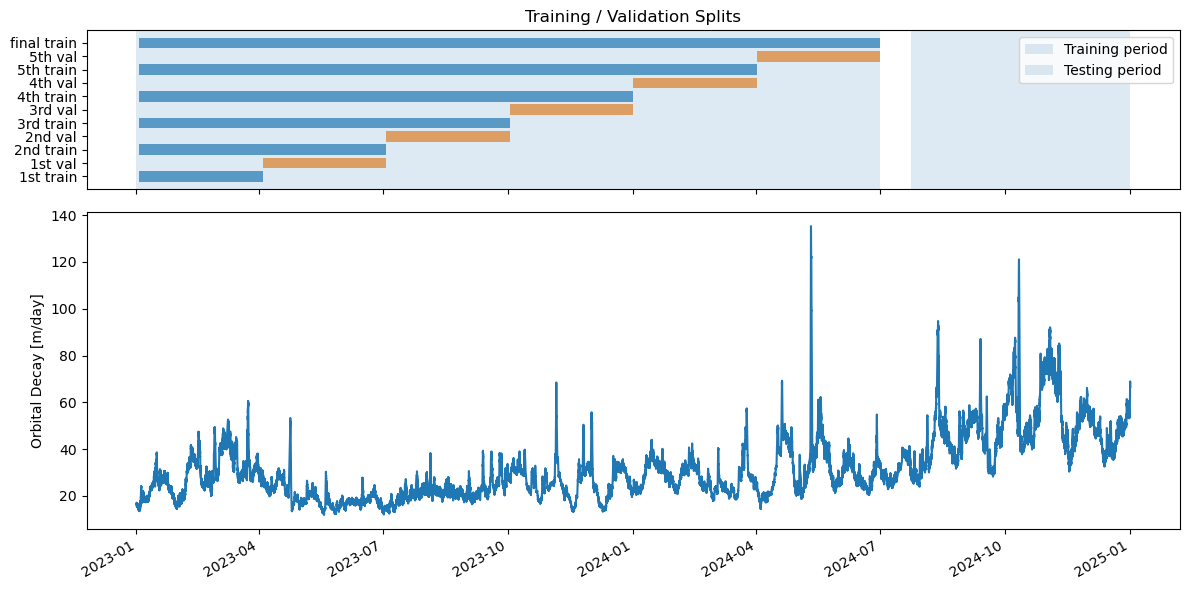

In [10]:
plot_folds(folds_df_3, GFOC_data, training_range, testing_range)